In [1]:
# =========================================================
# IMPORTS
# =========================================================
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
    print('xgboost not available; the notebook will use Logistic Regression and Random Forest.')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# =========================================================
# LOAD DATASET
# =========================================================
CSV_PATH = r"C:\Users\Rutik Bhendarkar\Chat Bot 2\Report Analysis\liver.csv"
# If you move the file next to this notebook, you can use:
# CSV_PATH = 'liver.csv'

df = pd.read_csv(CSV_PATH)
print('Dataset loaded successfully.')
display(df.head())
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

Dataset loaded successfully.


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


Shape: (583, 11)
Columns: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']


Info:
<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 52.8 KB
None

Missing values:
Age                           0
Gender                        0
Total_Bilirubi

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,44.746141,NaN,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,NaN,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,NaN,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,NaN,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,NaN,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,NaN,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000


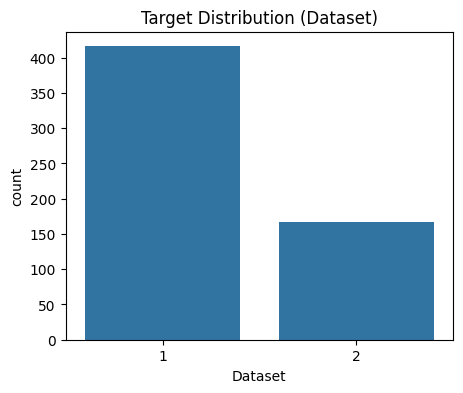

In [3]:
# =========================================================
# BASIC EDA
# =========================================================
print('Info:')
print(df.info())

print('\nMissing values:')
print(df.isnull().sum())

print('\nStatistical summary:')
display(df.describe(include='all'))

plt.figure(figsize=(5,4))
sns.countplot(x='Dataset', data=df)
plt.title('Target Distribution (Dataset)')
plt.show()

In [4]:
# =========================================================
# TARGET PREPARATION
# Dataset = 1 -> Liver disease present
# Dataset = 2 -> No liver disease
# =========================================================
df = df.copy()
df['target'] = (df['Dataset'] == 1).astype(int)

print(df['target'].value_counts())

# Optional: show disease/no-disease meaning clearly
target_meaning = {1: 'Liver disease', 0: 'No liver disease'}
print('\nTarget meaning:')
for k, v in target_meaning.items():
    print(k, '=>', v)

X = df.drop(columns=['Dataset', 'target'])
y = df['target']

target
1    416
0    167
Name: count, dtype: int64

Target meaning:
1 => Liver disease
0 => No liver disease


In [5]:
# =========================================================
# FEATURE INSPECTION
# =========================================================
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)

Numeric columns: ['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']
Categorical columns: ['Gender']


In [6]:
# =========================================================
# DATA CLEANING
# =========================================================
# Albumin_and_Globulin_Ratio has some missing values in this dataset.
# We will also handle any other missing values with a robust preprocessing pipeline.

df['Gender'] = df['Gender'].astype(str).str.strip().str.lower()
df['Gender'] = df['Gender'].map({'male': 1, 'female': 0})

# Rebuild features after gender conversion
X = df.drop(columns=['Dataset', 'target'])
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print('Cleaned feature types:')
print('Numeric:', numeric_cols)
print('Categorical:', categorical_cols)

Cleaned feature types:
Numeric: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']
Categorical: []


In [7]:
# =========================================================
# PREPROCESSING PIPELINE
# =========================================================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print('Preprocessing pipeline ready.')

Preprocessing pipeline ready.


In [8]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (466, 10)
Test shape: (117, 10)


In [9]:
# =========================================================
# TRAIN MODELS
# =========================================================
models = {}

models['Logistic Regression'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000))
])

models['Random Forest'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ))
])

if XGBOOST_AVAILABLE:
    models['XGBoost'] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric='logloss',
            random_state=42
        ))
    ])

print('Models:', list(models.keys()))

Models: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [10]:
# =========================================================
# EVALUATE MODELS
# =========================================================
results = []

for name, model in models.items():
    print(f'\nTraining {name}...')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    proba = None
    auc = np.nan
    try:
        proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, proba)
    except Exception:
        pass
    print('Accuracy:', round(acc, 4))
    if not np.isnan(auc):
        print('ROC-AUC:', round(auc, 4))
    print(classification_report(y_test, preds))
    results.append({'model': name, 'accuracy': acc, 'auc': auc, 'pipeline': model})

results_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)
display(results_df[['model', 'accuracy', 'auc']])


Training Logistic Regression...
Accuracy: 0.735
ROC-AUC: 0.8306
              precision    recall  f1-score   support

           0       0.67      0.18      0.28        34
           1       0.74      0.96      0.84        83

    accuracy                           0.74       117
   macro avg       0.70      0.57      0.56       117
weighted avg       0.72      0.74      0.68       117


Training Random Forest...
Accuracy: 0.735
ROC-AUC: 0.7845
              precision    recall  f1-score   support

           0       0.60      0.26      0.37        34
           1       0.75      0.93      0.83        83

    accuracy                           0.74       117
   macro avg       0.68      0.60      0.60       117
weighted avg       0.71      0.74      0.70       117


Training XGBoost...
Accuracy: 0.7094
ROC-AUC: 0.7587
              precision    recall  f1-score   support

           0       0.50      0.26      0.35        34
           1       0.75      0.89      0.81        83

    

,model,accuracy,auc
0,Logistic Regression,0.735043,0.830617
1,Random Forest,0.735043,0.784550
2,XGBoost,0.709402,0.758682


In [11]:
# =========================================================
# BEST MODEL
# =========================================================
best_row = results_df.iloc[0]
best_model_name = best_row['model']
best_model = best_row['pipeline']

print('Best model:', best_model_name)
print('Best accuracy:', round(best_row['accuracy'], 4))

Best model: Logistic Regression
Best accuracy: 0.735


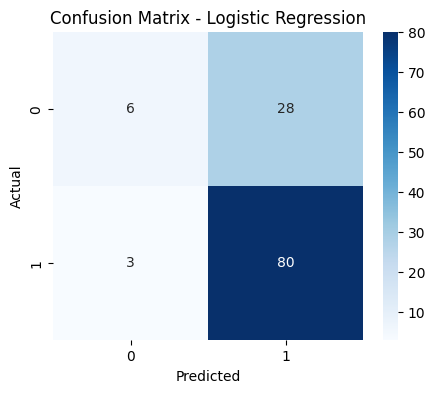

In [12]:
# =========================================================
# CONFUSION MATRIX
# =========================================================
best_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [13]:
# =========================================================
# SAVE MODEL ARTIFACTS
# =========================================================
os.makedirs('saved_models', exist_ok=True)
joblib.dump(best_model, 'saved_models/liver_model_pipeline.pkl')
joblib.dump(numeric_cols, 'saved_models/liver_numeric_cols.pkl')
joblib.dump(categorical_cols, 'saved_models/liver_categorical_cols.pkl')
joblib.dump({'best_model_name': best_model_name, 'target_definition': 'Dataset == 1 => Liver disease'}, 'saved_models/liver_meta.pkl')
print('Saved all liver artifacts into saved_models/')

Saved all liver artifacts into saved_models/


## Rule-based liver report analyzer
This section turns a structured liver report dictionary into an easy-to-read summary.

In [14]:
# =========================================================
# RULE-BASED LIVER ENGINE
# =========================================================
def liver_rule_engine(report):
    findings = []
    risk_score = 0

    def add_finding(parameter, severity, message, points):
        nonlocal risk_score
        findings.append({'parameter': parameter, 'severity': severity, 'message': message})
        risk_score += points

    age = report.get('Age')
    if age is not None:
        if age >= 60:
            add_finding('Age', 'MODERATE', 'Older age can increase liver-related risk.', 8)
        elif age >= 45:
            add_finding('Age', 'LOW', 'Middle age still needs regular monitoring.', 4)

    bilirubin = report.get('Total_Bilirubin')
    if bilirubin is not None:
        if bilirubin >= 3.0:
            add_finding('Total Bilirubin', 'CRITICAL', 'Very high bilirubin detected.', 25)
        elif bilirubin >= 1.5:
            add_finding('Total Bilirubin', 'HIGH', 'Raised bilirubin may indicate liver stress.', 16)

    direct_bilirubin = report.get('Direct_Bilirubin')
    if direct_bilirubin is not None and direct_bilirubin >= 1.0:
        add_finding('Direct Bilirubin', 'HIGH', 'Direct bilirubin is above normal.', 12)

    alk_phos = report.get('Alkaline_Phosphotase')
    if alk_phos is not None:
        if alk_phos >= 300:
            add_finding('Alkaline Phosphotase', 'HIGH', 'Elevated ALP can indicate liver or bile duct issues.', 14)
        elif alk_phos >= 200:
            add_finding('Alkaline Phosphotase', 'MODERATE', 'ALP is slightly elevated.', 8)

    alt = report.get('Alamine_Aminotransferase')
    if alt is not None:
        if alt >= 80:
            add_finding('ALT', 'HIGH', 'ALT is high and may show liver inflammation.', 15)
        elif alt >= 40:
            add_finding('ALT', 'MODERATE', 'ALT is somewhat elevated.', 8)

    ast = report.get('Aspartate_Aminotransferase')
    if ast is not None:
        if ast >= 80:
            add_finding('AST', 'HIGH', 'AST is high and may suggest liver damage.', 15)
        elif ast >= 40:
            add_finding('AST', 'MODERATE', 'AST is somewhat elevated.', 8)

    total_protein = report.get('Total_Protiens')
    if total_protein is not None and total_protein < 5.5:
        add_finding('Total Proteins', 'MODERATE', 'Low total protein may suggest reduced liver function or nutrition issues.', 8)

    albumin = report.get('Albumin')
    if albumin is not None:
        if albumin < 3.0:
            add_finding('Albumin', 'HIGH', 'Low albumin can be a sign of reduced liver function.', 14)
        elif albumin < 3.5:
            add_finding('Albumin', 'MODERATE', 'Albumin is slightly low.', 8)

    ag_ratio = report.get('Albumin_and_Globulin_Ratio')
    if ag_ratio is not None:
        if ag_ratio < 1.0:
            add_finding('A/G Ratio', 'MODERATE', 'Albumin/Globulin ratio is low.', 8)
        elif ag_ratio < 0.8:
            add_finding('A/G Ratio', 'HIGH', 'Albumin/Globulin ratio is very low.', 12)

    gender = str(report.get('Gender', '')).lower()
    if gender in ['male', '1']:
        add_finding('Gender', 'INFO', 'Male patients are statistically represented more often in this dataset.', 0)

    if risk_score >= 60:
        overall_risk = 'CRITICAL'
    elif risk_score >= 40:
        overall_risk = 'HIGH'
    elif risk_score >= 20:
        overall_risk = 'MODERATE'
    else:
        overall_risk = 'LOW'

    if overall_risk == 'CRITICAL':
        summary = 'Serious liver-risk pattern detected. Medical review is strongly recommended.'
    elif overall_risk == 'HIGH':
        summary = 'Important liver warning signs are present. Please consult a doctor soon.'
    elif overall_risk == 'MODERATE':
        summary = 'Some liver-related concerns are visible. Monitoring and follow-up are advised.'
    else:
        summary = 'No major liver-risk pattern detected.'

    recommendations = []
    if any(f['parameter'] == 'Total Bilirubin' and f['severity'] in ['HIGH', 'CRITICAL'] for f in findings):
        recommendations.append('Avoid alcohol and follow liver-friendly dietary habits.')
    if any(f['parameter'] in ['ALT', 'AST'] and f['severity'] in ['HIGH', 'CRITICAL'] for f in findings):
        recommendations.append('Repeat liver tests and consult a healthcare professional.')
    if any(f['parameter'] == 'Albumin' and f['severity'] in ['HIGH', 'CRITICAL'] for f in findings):
        recommendations.append('Monitor nutrition and liver function regularly.')
    if not recommendations:
        recommendations.append('Maintain a healthy lifestyle and regular checkups.')

    return {
        'findings': findings,
        'risk_score': risk_score,
        'overall_risk': overall_risk,
        'summary': summary,
        'recommendations': recommendations
    }

In [15]:
# =========================================================
# HUMAN-FRIENDLY EXPLANATION
# =========================================================
def generate_liver_human_explanation(result):
    lines = []
    lines.append('=== Liver Report Explanation ===')
    lines.append(f"Overall Risk Level: {result.get('overall_risk', 'UNKNOWN')}")
    lines.append(result.get('summary', 'No summary available.'))
    lines.append('')
    lines.append('What this means:')
    meaning_map = {
        'LOW': 'This report does not show a major liver warning pattern.',
        'MODERATE': 'This report shows some liver-related changes and should be monitored.',
        'HIGH': 'This report shows important warning signs and should be reviewed by a doctor.',
        'CRITICAL': 'This report shows serious warning signs and may need urgent medical attention.'
    }
    lines.append(meaning_map.get(result.get('overall_risk', 'UNKNOWN'), 'Risk meaning not available.'))
    lines.append('')
    lines.append('Detailed Findings:')
    findings = result.get('findings', [])
    if findings:
        for item in findings:
            lines.append(f"- {item['parameter']} [{item['severity']}]: {item['message']}")
    else:
        lines.append('- No significant abnormal findings detected.')
    lines.append('')
    lines.append('Recommendations:')
    for rec in result.get('recommendations', []):
        lines.append(f'- {rec}')
    lines.append('')
    lines.append('Simple take-away:')
    if result.get('overall_risk') in ['HIGH', 'CRITICAL']:
        lines.append('This report deserves medical attention and careful follow-up.')
    elif result.get('overall_risk') == 'MODERATE':
        lines.append('This report should be monitored and rechecked if needed.')
    else:
        lines.append('This report looks mostly stable based on the current values.')
    return '\n'.join(lines)

In [16]:
# =========================================================
# FINAL SUMMARY ENGINE WITH EXTRA CLARITY
# =========================================================
def generate_final_liver_summary(result, model_result=None):
    lines = []
    lines.append('=========== AI LIVER REPORT SUMMARY ===========')
    lines.append('')
    lines.append(f"Overall Health Risk Level: {result.get('overall_risk', 'UNKNOWN')}")
    lines.append(result.get('summary', 'No summary available.'))
    lines.append('')
    if model_result is not None:
        lines.append('AI Model Prediction:')
        pred = model_result.get('prediction', 0)
        prob = float(model_result.get('probability', 0))
        if pred == 1:
            lines.append('- AI predicts liver disease risk is elevated.')
        else:
            lines.append('- AI predicts lower liver disease risk.')
        lines.append(f'- Risk Probability: {prob}%')
        if prob >= 85:
            lines.append('- Confidence level: VERY HIGH')
        elif prob >= 70:
            lines.append('- Confidence level: HIGH')
        elif prob >= 50:
            lines.append('- Confidence level: MODERATE')
        else:
            lines.append('- Confidence level: LOW')
        lines.append('')
    lines.append('Abnormal Findings:')
    findings = result.get('findings', [])
    if findings:
        for item in findings:
            lines.append(f"- {item['parameter']} [{item['severity']}] -> {item['message']}")
    else:
        lines.append('- No major abnormal findings detected.')
    lines.append('')
    lines.append('What this means in simple words:')
    if result.get('overall_risk') == 'CRITICAL':
        lines.append('- The report shows serious liver-related concern.')
        lines.append('- A doctor should review the results soon.')
    elif result.get('overall_risk') == 'HIGH':
        lines.append('- The report shows clear warning signs.')
        lines.append('- Medical follow-up is recommended.')
    elif result.get('overall_risk') == 'MODERATE':
        lines.append('- The report shows some changes that should be monitored.')
    else:
        lines.append('- The report does not show a major warning pattern right now.')
    lines.append('')
    lines.append('Future Health Forecast:')
    findings_text = str(findings).lower()
    future_risks = []
    if 'bilirubin' in findings_text:
        future_risks.append('Bilirubin-related issues may worsen if the liver stays stressed.')
    if 'alt' in findings_text or 'ast' in findings_text:
        future_risks.append('Inflammation markers may suggest ongoing liver strain.')
    if 'albumin' in findings_text:
        future_risks.append('Low albumin may affect nutrition and liver function over time.')
    if 'a/g ratio' in findings_text:
        future_risks.append('Low A/G ratio can indicate imbalance in liver-related proteins.')
    if future_risks:
        for risk in future_risks:
            lines.append(f'- {risk}')
    else:
        lines.append('- No strong future complication pattern detected.')
    lines.append('')
    lines.append('Medical Recommendations:')
    for rec in result.get('recommendations', []):
        lines.append(f'- {rec}')
    lines.append('')
    if any(item['severity'] == 'CRITICAL' for item in findings):
        lines.append('⚠ IMPORTANT WARNING:')
        lines.append('One or more values are critically abnormal.')
        lines.append('Please seek medical consultation as soon as possible.')
        lines.append('')
    lines.append('Next Steps:')
    if result.get('overall_risk') in ['HIGH', 'CRITICAL']:
        lines.append('- Review the report with a doctor.')
        lines.append('- Avoid alcohol and follow liver-friendly habits.')
    elif result.get('overall_risk') == 'MODERATE':
        lines.append('- Monitor the values and repeat tests if advised.')
    else:
        lines.append('- Continue healthy habits and routine checkups.')
    lines.append('')
    lines.append('This AI-generated summary is for educational and supportive analysis only and does not replace medical advice.')
    return '\n'.join(lines)

In [17]:
# =========================================================
# MODEL-STYLE PREDICTION FUNCTION FROM STRUCTURED REPORT
# =========================================================
def predict_liver_risk(report_dict, model_pipeline=best_model):
    input_df = pd.DataFrame([report_dict])
    prob = float(model_pipeline.predict_proba(input_df)[0, 1] * 100)
    pred = int(prob >= 50)
    return {'prediction': pred, 'probability': round(prob, 2)}

In [18]:
# =========================================================
# EXAMPLE REPORT TEST
# =========================================================
sample_report = {
    'Age': 65,
    'Gender': 1,
    'Total_Bilirubin': 3.2,
    'Direct_Bilirubin': 1.4,
    'Alkaline_Phosphotase': 345,
    'Alamine_Aminotransferase': 88,
    'Aspartate_Aminotransferase': 95,
    'Total_Protiens': 5.8,
    'Albumin': 2.9,
    'Albumin_and_Globulin_Ratio': 0.7
}

rule_result = liver_rule_engine(sample_report)
model_result = predict_liver_risk(sample_report)

print(generate_liver_human_explanation(rule_result))
print('\n' + '='*80 + '\n')
print(generate_final_liver_summary(rule_result, model_result))

=== Liver Report Explanation ===
Overall Risk Level: CRITICAL
Serious liver-risk pattern detected. Medical review is strongly recommended.

What this means:
This report shows serious warning signs and may need urgent medical attention.

Detailed Findings:
- Age [MODERATE]: Older age can increase liver-related risk.
- Total Bilirubin [CRITICAL]: Very high bilirubin detected.
- Direct Bilirubin [HIGH]: Direct bilirubin is above normal.
- Alkaline Phosphotase [HIGH]: Elevated ALP can indicate liver or bile duct issues.
- ALT [HIGH]: ALT is high and may show liver inflammation.
- AST [HIGH]: AST is high and may suggest liver damage.
- Albumin [HIGH]: Low albumin can be a sign of reduced liver function.
- A/G Ratio [MODERATE]: Albumin/Globulin ratio is low.
- Gender [INFO]: Male patients are statistically represented more often in this dataset.

Recommendations:
- Avoid alcohol and follow liver-friendly dietary habits.
- Repeat liver tests and consult a healthcare professional.
- Monitor nu